# Redes Neuronales II — Notebook 02
## Clasificación binaria con datos reales: *Breast Cancer Wisconsin (Diagnostic)*

**Objetivo.** Rediseñar y optimizar los modelos del Notebook 01 (perceptrón, red de una capa y MLP con backpropagation) y aplicarlos a un problema real de **clasificación binaria**: predecir si un tumor es **maligno (0)** o **benigno (1)** a partir de 30 características morfológicas de núcleos celulares.

Flujo de trabajo supervisado:
1. Carga y análisis exploratorio.
2. Partición estratificada *train / validación / test* (60/20/20) y estandarización.
3. Modelos base: Perceptrón y red de una capa.
4. MLP con backpropagation: comparación **Sigmoide vs ReLU**.
5. Optimización: búsqueda de hiperparámetros con validación cruzada (5 folds), *early stopping* y regularización L2.
6. Evaluación final en test (exactitud, precisión, *recall*, F1, ROC-AUC, matriz de confusión).
7. Réplica del mejor MLP en TensorFlow + Keras como control.

In [1]:
import os, itertools, time
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # silencia logs de TensorFlow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve)

SEED = 42
np.random.seed(SEED)
os.makedirs("figures", exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

### Implementaciones NumPy (reutilizadas del Notebook 01)
Se incluyen aquí para que el notebook sea autocontenido en Colab. Son idénticas a `src/nn_numpy.py` del repositorio.

In [2]:
def step(z):        return (z >= 0).astype(float)
def sigmoid(z):     return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))
def d_sigmoid(z):   s = sigmoid(z); return s * (1 - s)
def tanh(z):        return np.tanh(z)
def d_tanh(z):      return 1 - np.tanh(z) ** 2
def relu(z):        return np.maximum(0, z)
def d_relu(z):      return (z > 0).astype(float)
def softmax(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))   # estabilidad numérica
    return e / e.sum(axis=1, keepdims=True)

ACTIVATIONS = {"sigmoid": (sigmoid, d_sigmoid), "tanh": (tanh, d_tanh), "relu": (relu, d_relu)}


class Perceptron:
    """Perceptrón de Rosenblatt con activación escalón."""
    def __init__(self, lr=0.1, epochs=50, seed=SEED):
        self.lr, self.epochs, self.rng = lr, epochs, np.random.default_rng(seed)

    def fit(self, X, y):
        self.w = self.rng.normal(0, 0.01, X.shape[1]); self.b = 0.0
        self.errors_ = []
        for _ in range(self.epochs):
            errors = 0
            for i in self.rng.permutation(len(X)):
                update = self.lr * (y[i] - self.predict(X[i:i+1])[0])
                self.w += update * X[i]; self.b += update
                errors += int(update != 0)
            self.errors_.append(errors)
            if errors == 0:          # convergió
                break
        return self

    def decision_function(self, X): return X @ self.w + self.b
    def predict(self, X):           return step(self.decision_function(X))
    def score(self, X, y):          return (self.predict(X) == y).mean()

class SingleLayerNet:
    """Red de una capa: una neurona sigmoide + entropía cruzada + descenso de gradiente (batch)."""
    def __init__(self, lr=0.5, epochs=2000, l2=0.0, seed=SEED):
        self.lr, self.epochs, self.l2, self.rng = lr, epochs, l2, np.random.default_rng(seed)

    def fit(self, X, y):
        m = len(X)
        self.w = self.rng.normal(0, 0.01, X.shape[1]); self.b = 0.0
        self.loss_ = []
        for _ in range(self.epochs):
            p = sigmoid(X @ self.w + self.b)                     # forward
            self.loss_.append(bce(y, p) + 0.5 * self.l2 * np.sum(self.w**2) / m)
            dz = (p - y) / m                                      # backward
            self.w -= self.lr * (X.T @ dz + self.l2 * self.w / m)
            self.b -= self.lr * dz.sum()
        return self

    def predict_proba(self, X): return sigmoid(X @ self.w + self.b)
    def predict(self, X):       return (self.predict_proba(X) >= 0.5).astype(float)
    def score(self, X, y):      return (self.predict(X) == y).mean()

def bce(y, p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))


class MLP:
    """Perceptrón multicapa en NumPy con backpropagation.

    layers: p. ej. [n_features, 16, 8, 1]. Salida sigmoide si la última capa tiene 1 neurona
    (clasificación binaria), softmax si tiene >1 (multiclase).
    """
    def __init__(self, layers, hidden="relu", lr=0.05, epochs=500, batch_size=32,
                 momentum=0.9, l2=0.0, seed=SEED, verbose=0):
        self.layers, self.hidden = layers, hidden
        self.g, self.dg = ACTIVATIONS[hidden]
        self.lr, self.epochs, self.bs = lr, epochs, batch_size
        self.beta, self.l2, self.verbose = momentum, l2, verbose
        self.rng = np.random.default_rng(seed)
        self.binary = layers[-1] == 1
        self._init_params()

    def _init_params(self):
        self.W, self.b = [], []
        for n_in, n_out in zip(self.layers[:-1], self.layers[1:]):
            scale = np.sqrt(2.0 / n_in) if self.hidden == "relu" else np.sqrt(1.0 / n_in)  # He / Xavier
            self.W.append(self.rng.normal(0, scale, (n_in, n_out)))
            self.b.append(np.zeros((1, n_out)))
        self.vW = [np.zeros_like(w) for w in self.W]
        self.vb = [np.zeros_like(b) for b in self.b]

    # ---------- forward ----------
    def forward(self, X):
        A, cache = X, [(None, X)]
        for l, (W, b) in enumerate(zip(self.W, self.b)):
            Z = A @ W + b
            last = l == len(self.W) - 1
            A = (sigmoid(Z) if self.binary else softmax(Z)) if last else self.g(Z)
            cache.append((Z, A))
        return A, cache

    def loss(self, Y, A):
        data = bce(Y, A) if self.binary else -np.mean(np.sum(Y * np.log(np.clip(A, 1e-12, 1)), axis=1))
        reg = 0.5 * self.l2 * sum(np.sum(W**2) for W in self.W) / len(Y)
        return data + reg

    # ---------- backward ----------
    def backward(self, Y, cache):
        m = len(Y)
        gW, gb = [None] * len(self.W), [None] * len(self.W)
        delta = cache[-1][1] - Y                                   # δ^[L]
        for l in reversed(range(len(self.W))):
            A_prev = cache[l][1]
            gW[l] = A_prev.T @ delta / m + self.l2 * self.W[l] / m
            gb[l] = delta.sum(axis=0, keepdims=True) / m
            if l > 0:
                delta = (delta @ self.W[l].T) * self.dg(cache[l][0])  # δ^[l-1]
        return gW, gb

    def _step(self, gW, gb):
        for l in range(len(self.W)):
            self.vW[l] = self.beta * self.vW[l] - self.lr * gW[l]; self.W[l] += self.vW[l]
            self.vb[l] = self.beta * self.vb[l] - self.lr * gb[l]; self.b[l] += self.vb[l]

    def _prep_y(self, y):
        y = np.asarray(y)
        if self.binary: return y.reshape(-1, 1).astype(float)
        return np.eye(self.layers[-1])[y.astype(int)]

    def fit(self, X, y, X_val=None, y_val=None):
        Y = self._prep_y(y)
        self.history = {"loss": [], "acc": [], "val_loss": [], "val_acc": []}
        for ep in range(self.epochs):
            idx = self.rng.permutation(len(X))
            for s in range(0, len(X), self.bs):
                bi = idx[s:s + self.bs]
                A, cache = self.forward(X[bi])
                self._step(*self.backward(Y[bi], cache))
            A, _ = self.forward(X)
            self.history["loss"].append(self.loss(Y, A)); self.history["acc"].append(self.score(X, y))
            if X_val is not None:
                Av, _ = self.forward(X_val)
                self.history["val_loss"].append(self.loss(self._prep_y(y_val), Av))
                self.history["val_acc"].append(self.score(X_val, y_val))
            if self.verbose and (ep + 1) % self.verbose == 0:
                msg = f"época {ep+1:4d} | pérdida {self.history['loss'][-1]:.4f} | acc {self.history['acc'][-1]:.3f}"
                if X_val is not None: msg += f" | val_pérdida {self.history['val_loss'][-1]:.4f} | val_acc {self.history['val_acc'][-1]:.3f}"
                print(msg)
        return self

    def predict_proba(self, X): return self.forward(X)[0]
    def predict(self, X):
        A = self.predict_proba(X)
        return (A[:, 0] >= 0.5).astype(float) if self.binary else A.argmax(axis=1)
    def score(self, X, y): return (self.predict(X) == np.asarray(y)).mean()

## 1. Carga y exploración del dataset

In [3]:
data = load_breast_cancer()
X, y = data.data, data.target.astype(float)
df = pd.DataFrame(X, columns=data.feature_names); df["target"] = y
print("Forma:", X.shape)
print("Clases:", dict(zip(data.target_names, np.bincount(data.target))))
df.iloc[:, [0, 1, 2, 3, 4, 20, 27, 30]].describe().T.round(2)

Forma: (569, 30)
Clases: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.13,3.52,6.98,11.70,13.37,15.78,28.11
mean texture,569.0,19.29,4.30,9.71,16.17,18.84,21.80,39.28
mean perimeter,569.0,91.97,24.30,43.79,75.17,86.24,104.10,188.50
mean area,569.0,654.89,351.91,143.50,420.30,551.10,782.70,2501.00
mean smoothness,569.0,0.10,0.01,0.05,0.09,0.10,0.11,0.16
worst radius,569.0,16.27,4.83,7.93,13.01,14.97,18.79,36.04
worst concave points,569.0,0.11,0.07,0.00,0.06,0.10,0.16,0.29
target,569.0,0.63,0.48,0.00,0.00,1.00,1.00,1.00


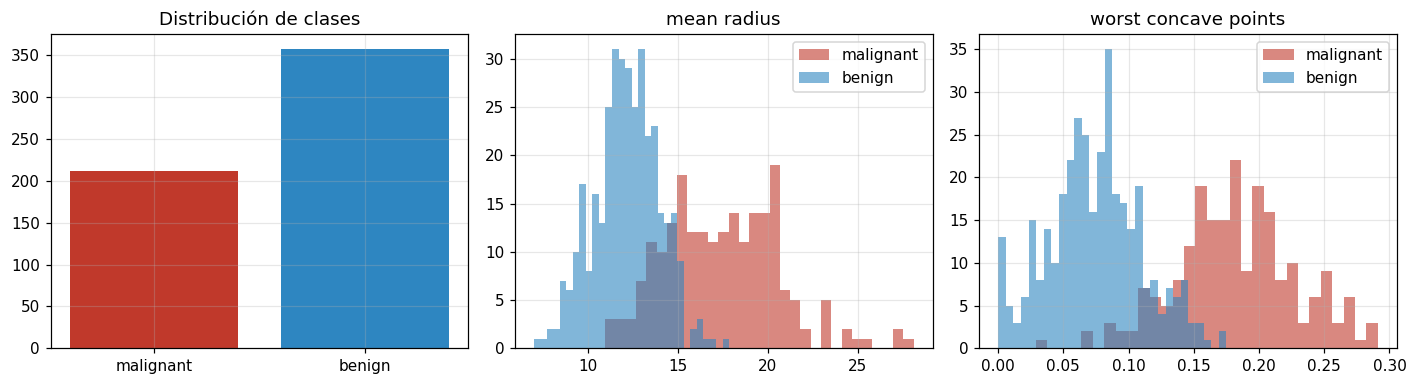

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].bar(data.target_names, np.bincount(data.target), color=["#c0392b", "#2e86c1"])
axes[0].set_title("Distribución de clases")
for a, feat in zip(axes[1:], ["mean radius", "worst concave points"]):
    for cls, col in [(0, "#c0392b"), (1, "#2e86c1")]:
        a.hist(df.loc[df.target == cls, feat], bins=30, alpha=0.6, color=col, label=data.target_names[cls])
    a.set_title(feat); a.legend()
plt.tight_layout(); plt.savefig("figures/02_eda.png", bbox_inches="tight"); plt.show()

El conjunto está moderadamente desbalanceado (37 % malignos / 63 % benignos) y las variables tienen escalas muy distintas (p. ej. *area* ~ $10^3$ frente a *smoothness* ~ $10^{-1}$), por lo que la **estandarización** es imprescindible para el descenso de gradiente.

## 2. Partición y estandarización
El `StandardScaler` se ajusta **sólo con train** para evitar fuga de información.

In [5]:
X_tmp, X_te, y_tmp, y_te = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)
X_tr, X_va, y_tr, y_va = train_test_split(X_tmp, y_tmp, test_size=0.25, stratify=y_tmp, random_state=SEED)
scaler = StandardScaler().fit(X_tr)
X_tr, X_va, X_te = scaler.transform(X_tr), scaler.transform(X_va), scaler.transform(X_te)
print(f"train={X_tr.shape}, val={X_va.shape}, test={X_te.shape}")

def metrics(y_true, y_pred, y_score=None):
    out = {"Exactitud": accuracy_score(y_true, y_pred), "Precisión": precision_score(y_true, y_pred),
           "Recall": recall_score(y_true, y_pred), "F1": f1_score(y_true, y_pred)}
    out["Recall malignos"] = recall_score(y_true, y_pred, pos_label=0)   # sensibilidad para la clase crítica
    out["ROC-AUC"] = roc_auc_score(y_true, y_score) if y_score is not None else np.nan
    return out

train=(341, 30), val=(114, 30), test=(114, 30)


## 3. Modelos base: perceptrón y red de una capa

In [6]:
results = {}
per = Perceptron(lr=0.01, epochs=100).fit(X_tr, y_tr)
results["Perceptrón"] = metrics(y_va, per.predict(X_va), per.decision_function(X_va))
sln = SingleLayerNet(lr=0.1, epochs=1000, l2=1.0).fit(X_tr, y_tr)
results["Red de una capa"] = metrics(y_va, sln.predict(X_va), sln.predict_proba(X_va))
pd.DataFrame(results).T.round(4)

,Exactitud,Precisión,Recall,F1,Recall malignos,ROC-AUC
Perceptrón,0.9649,0.9718,0.9718,0.9718,0.9535,0.9951
Red de una capa,0.9825,0.9726,1.0000,0.9861,0.9535,0.9980


Ambos modelos lineales ya obtienen resultados altos: este problema es **casi linealmente separable**. El perceptrón no converge a cero errores (los datos no son perfectamente separables), por lo que oscila; la red de una capa, al optimizar una pérdida continua, es más estable.

## 4. MLP con backpropagation: Sigmoide vs ReLU

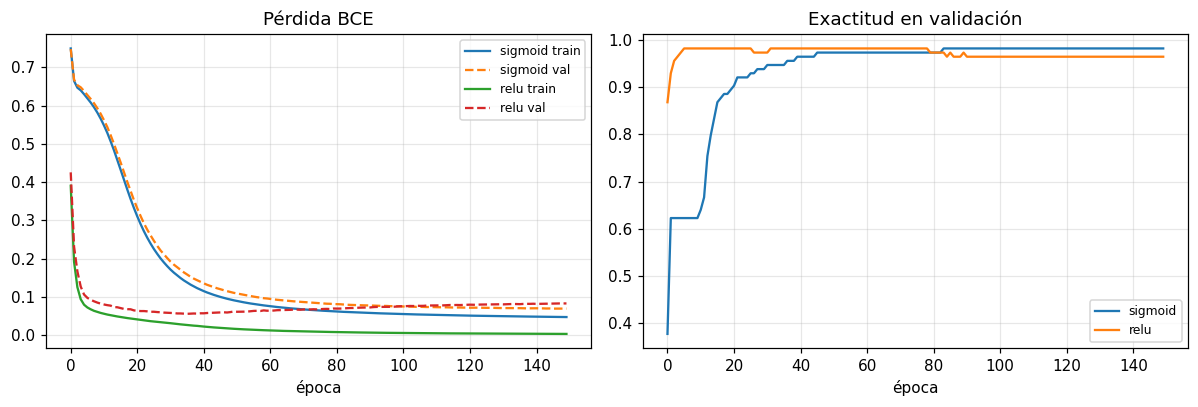

,Exactitud,Precisión,Recall,F1,Recall malignos,ROC-AUC
Perceptrón,0.9649,0.9718,0.9718,0.9718,0.9535,0.9951
Red de una capa,0.9825,0.9726,1.0000,0.9861,0.9535,0.9980
MLP 30-16-8-1 sigmoid,0.9825,0.9726,1.0000,0.9861,0.9535,0.9971
MLP 30-16-8-1 relu,0.9649,0.9718,0.9718,0.9718,0.9535,0.9967


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for hidden in ["sigmoid", "relu"]:
    mlp = MLP([30, 16, 8, 1], hidden=hidden, lr=0.01, epochs=150, batch_size=32).fit(X_tr, y_tr, X_va, y_va)
    ax[0].plot(mlp.history["loss"], label=f"{hidden} train"); ax[0].plot(mlp.history["val_loss"], "--", label=f"{hidden} val")
    ax[1].plot(mlp.history["val_acc"], label=hidden)
    results[f"MLP 30-16-8-1 {hidden}"] = metrics(y_va, mlp.predict(X_va), mlp.predict_proba(X_va)[:, 0])
ax[0].set_title("Pérdida BCE"); ax[1].set_title("Exactitud en validación")
for a in ax: a.set_xlabel("época"); a.legend(fontsize=8)
plt.tight_layout(); plt.savefig("figures/02_sigmoide_vs_relu.png", bbox_inches="tight"); plt.show()
pd.DataFrame(results).T.round(4)

* **ReLU** converge en muy pocas épocas, pero sin regularización su pérdida de entrenamiento sigue bajando mientras la de validación toca mínimo (~época 35) y vuelve a subir: señal de **sobreajuste**.
* **Sigmoide** pasa varias épocas estancada prediciendo la clase mayoritaria (exactitud ≈ 0.62) antes de salir de la zona de saturación, y necesita ~5× más épocas para llegar a la misma pérdida.

Esto motiva la búsqueda de hiperparámetros con L2 y *early stopping*.

## 5. Optimización: búsqueda de hiperparámetros con validación cruzada + *early stopping*

Se extiende la clase `MLP` con **parada temprana**: se monitoriza la pérdida de validación y se restauran los pesos de la mejor época si no mejora durante `patience` épocas.

In [8]:
class MLPEarlyStopping(MLP):
    def __init__(self, *args, patience=20, **kw):
        super().__init__(*args, **kw); self.patience = patience

    def fit(self, X, y, X_val, y_val):
        Y, Yv = self._prep_y(y), self._prep_y(y_val)
        self.history = {"loss": [], "acc": [], "val_loss": [], "val_acc": []}
        best, wait = np.inf, 0
        for ep in range(self.epochs):
            idx = self.rng.permutation(len(X))
            for s in range(0, len(X), self.bs):
                bi = idx[s:s + self.bs]; A, cache = self.forward(X[bi]); self._step(*self.backward(Y[bi], cache))
            vl = self.loss(Yv, self.forward(X_val)[0])
            self.history["loss"].append(self.loss(Y, self.forward(X)[0])); self.history["acc"].append(self.score(X, y))
            self.history["val_loss"].append(vl); self.history["val_acc"].append(self.score(X_val, y_val))
            if vl < best - 1e-5:
                best, wait, self.best_epoch = vl, 0, ep + 1
                self._best = ([w.copy() for w in self.W], [b.copy() for b in self.b])
            else:
                wait += 1
                if wait >= self.patience: break
        self.W, self.b = self._best
        return self

grid = {"hidden_layers": [(16,), (32, 16), (64, 32)], "activation": ["sigmoid", "relu"],
        "lr": [0.005, 0.02], "l2": [0.0, 5.0]}

# Validación cruzada estratificada de 5 particiones sobre train+validación (455 muestras):
# una sola partición de validación (114 muestras) es demasiado ruidosa para elegir hiperparámetros.
X_dev, y_dev = np.vstack([X_tr, X_va]), np.concatenate([y_tr, y_va])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
rows, t0 = [], time.time()
for hl, act, lr, l2 in itertools.product(*grid.values()):
    losses, accs, epochs = [], [], []
    for k, (i_tr, i_va) in enumerate(skf.split(X_dev, y_dev)):
        sc = StandardScaler().fit(X_dev[i_tr])      # escalador ajustado dentro de cada fold
        a, b = sc.transform(X_dev[i_tr]), sc.transform(X_dev[i_va])
        m = MLPEarlyStopping([30, *hl, 1], hidden=act, lr=lr, l2=l2, epochs=400, batch_size=32,
                             patience=25, seed=SEED + k).fit(a, y_dev[i_tr], b, y_dev[i_va])
        losses.append(min(m.history["val_loss"])); accs.append(m.score(b, y_dev[i_va])); epochs.append(m.best_epoch)
    rows.append({"capas": str(hl), "activación": act, "lr": lr, "l2": l2, "épocas (media)": np.mean(epochs),
                 "cv_loss": np.mean(losses), "cv_loss_std": np.std(losses), "cv_acc": np.mean(accs)})
search = pd.DataFrame(rows).sort_values("cv_loss").reset_index(drop=True)
print(f"{len(rows)} configuraciones × 5 folds = {5*len(rows)} entrenamientos en {time.time()-t0:.1f} s")
search.head(10).round(4)

24 configuraciones × 5 folds = 120 entrenamientos en 32.0 s


,capas,activación,lr,l2,épocas (media),cv_loss,cv_loss_std,cv_acc
0,"(16,)",relu,0.020,0.0,102.0,0.0570,0.0351,0.9824
1,"(64, 32)",sigmoid,0.020,0.0,121.0,0.0622,0.0378,0.9780
2,"(64, 32)",relu,0.005,0.0,122.2,0.0645,0.0564,0.9780
3,"(32, 16)",relu,0.020,0.0,28.4,0.0647,0.0394,0.9846
4,"(64, 32)",sigmoid,0.005,0.0,236.6,0.0663,0.0360,0.9758
5,"(64, 32)",relu,0.020,0.0,41.8,0.0665,0.0559,0.9802
6,"(16,)",sigmoid,0.020,0.0,72.2,0.0672,0.0339,0.9758
7,"(32, 16)",sigmoid,0.020,0.0,66.2,0.0673,0.0350,0.9780
8,"(16,)",sigmoid,0.005,0.0,243.6,0.0680,0.0332,0.9780
9,"(16,)",relu,0.005,0.0,125.0,0.0685,0.0284,0.9824


In [9]:
print(search.groupby("activación")[["cv_loss", "cv_acc"]].agg(["mean", "min", "max"]).round(4))
best_cfg = search.iloc[0]
print("\nMejor configuración (mínima pérdida media en validación cruzada):\n", best_cfg.to_dict())

           cv_loss                  cv_acc                
              mean     min     max    mean     min     max
activación                                                
relu        0.1535  0.0570  0.2566  0.9694  0.9516  0.9846
sigmoid     0.3322  0.0622  0.6609  0.8436  0.6264  0.9780

Mejor configuración (mínima pérdida media en validación cruzada):
 {'capas': '(16,)', 'activación': 'relu', 'lr': 0.02, 'l2': 0.0, 'épocas (media)': 102.0, 'cv_loss': 0.056958709823639674, 'cv_loss_std': 0.03507203001010826, 'cv_acc': 0.9824175824175825}


## 6. Evaluación final en el conjunto de test

El modelo final se reentrena con la mejor configuración y se evalúa **una sola vez** en test, que no se usó en ninguna decisión previa.

In [10]:
hl = eval(best_cfg["capas"])
best = MLPEarlyStopping([30, *hl, 1], hidden=best_cfg["activación"], lr=best_cfg["lr"], l2=best_cfg["l2"],
                        epochs=400, batch_size=32, patience=25).fit(X_tr, y_tr, X_va, y_va)
p_te = best.predict_proba(X_te)[:, 0]
final = {
    "Perceptrón": metrics(y_te, per.predict(X_te), per.decision_function(X_te)),
    "Red de una capa": metrics(y_te, sln.predict(X_te), sln.predict_proba(X_te)),
    f"MLP optimizado {best_cfg['capas']} {best_cfg['activación']}": metrics(y_te, (p_te >= 0.5).astype(float), p_te),
}
final_df = pd.DataFrame(final).T.round(4)
final_df

,Exactitud,Precisión,Recall,F1,Recall malignos,ROC-AUC
Perceptrón,0.9474,0.9583,0.9583,0.9583,0.9286,0.9861
Red de una capa,0.9825,0.9861,0.9861,0.9861,0.9762,0.9964
"MLP optimizado (16,) relu",0.9649,0.9722,0.9722,0.9722,0.9524,0.9884


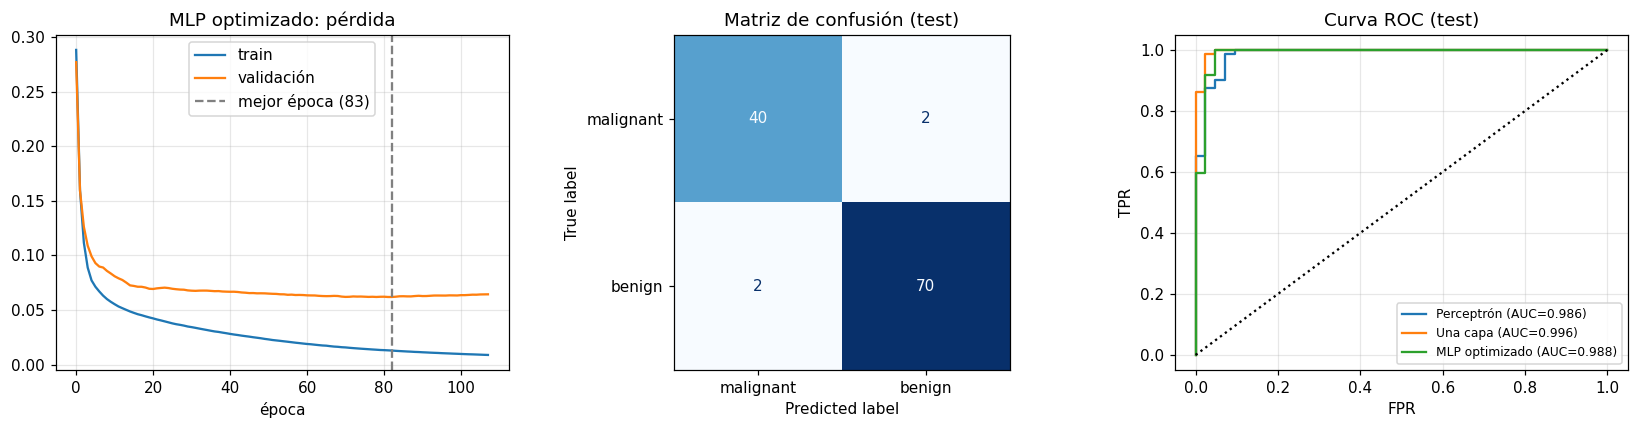

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(best.history["loss"], label="train"); ax[0].plot(best.history["val_loss"], label="validación")
ax[0].axvline(best.best_epoch - 1, ls="--", c="gray", label=f"mejor época ({best.best_epoch})")
ax[0].set_title("MLP optimizado: pérdida"); ax[0].set_xlabel("época"); ax[0].legend()
ConfusionMatrixDisplay(confusion_matrix(y_te, (p_te >= 0.5)), display_labels=data.target_names).plot(ax=ax[1], cmap="Blues", colorbar=False)
ax[1].set_title("Matriz de confusión (test)"); ax[1].grid(False)
for name, score in [("Perceptrón", per.decision_function(X_te)), ("Una capa", sln.predict_proba(X_te)), ("MLP optimizado", p_te)]:
    fpr, tpr, _ = roc_curve(y_te, score); ax[2].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_te, score):.3f})")
ax[2].plot([0, 1], [0, 1], "k:"); ax[2].set_title("Curva ROC (test)"); ax[2].set_xlabel("FPR"); ax[2].set_ylabel("TPR"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.savefig("figures/02_evaluacion_test.png", bbox_inches="tight"); plt.show()

## 7. Control: mismo MLP en TensorFlow + Keras
Se replica la mejor arquitectura con Keras (misma activación, inicialización, SGD con momentum, L2 y *early stopping*) para contrastar la implementación manual con un framework.

In [12]:
import tensorflow as tf
from tensorflow import keras
tf.random.set_seed(SEED); keras.utils.set_random_seed(SEED)
init = "he_normal" if best_cfg["activación"] == "relu" else "glorot_normal"
# En la MLP NumPy el gradiente L2 por mini-lote es l2·W/batch  ⇒  equivalente Keras: λ = l2 / (2·batch)
reg = keras.regularizers.l2(best_cfg["l2"] / (2 * 32)) if best_cfg["l2"] > 0 else None
keras_bin = keras.Sequential([keras.Input(shape=(30,))] +
    [keras.layers.Dense(n, activation=best_cfg["activación"], kernel_initializer=init, kernel_regularizer=reg) for n in hl] +
    [keras.layers.Dense(1, activation="sigmoid")])
keras_bin.compile(optimizer=keras.optimizers.SGD(learning_rate=best_cfg["lr"], momentum=0.9),
                  loss="binary_crossentropy", metrics=["accuracy", keras.metrics.AUC(name="auc")])
keras_bin.summary()
hist = keras_bin.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=400, batch_size=32, verbose=0,
                     callbacks=[keras.callbacks.EarlyStopping(patience=25, restore_best_weights=True)])
pk = keras_bin.predict(X_te, verbose=0)[:, 0]
final_df.loc["Keras (misma arquitectura)"] = pd.Series(metrics(y_te, (pk >= 0.5).astype(float), pk)).round(4)
print("Épocas ejecutadas en Keras:", len(hist.history["loss"]))
final_df

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

Épocas ejecutadas en Keras: 77


,Exactitud,Precisión,Recall,F1,Recall malignos,ROC-AUC
Perceptrón,0.9474,0.9583,0.9583,0.9583,0.9286,0.9861
Red de una capa,0.9825,0.9861,0.9861,0.9861,0.9762,0.9964
"MLP optimizado (16,) relu",0.9649,0.9722,0.9722,0.9722,0.9524,0.9884
Keras (misma arquitectura),0.9386,0.9851,0.9167,0.9496,0.9762,0.9924


In [13]:
final_df.to_csv("figures/02_resultados_test.csv")

## 8. Análisis de resultados

* **Todos los modelos superan el 93 % de exactitud y 0.98 de ROC-AUC en test.** El dataset es casi linealmente separable, así que la red de una capa (2 errores de 114) queda por delante del MLP optimizado (4 errores). La diferencia equivale a 2 muestras y está dentro de la variabilidad esperable con un test de 114 casos: en datos casi lineales la capacidad adicional del MLP no aporta y el modelo más simple es preferible (navaja de Occam).
* **El perceptrón** es el más débil (6 errores; recall de malignos 0.93): al no minimizar una pérdida continua, su frontera depende del orden de presentación de las muestras y no produce probabilidades calibradas.
* **Sigmoide vs ReLU.** En la validación cruzada ReLU es mucho más **robusta a los hiperparámetros** (exactitud media 0.969 frente a 0.844). Con tasa de aprendizaje baja y L2 fuerte, la red sigmoide queda atrapada cerca de la predicción constante (exactitud mínima 0.63 = proporción de la clase mayoritaria), un efecto de la saturación y del gradiente acotado por 0.25. ReLU además converge en menos épocas.
* **Regularización.** L2 = 5 resultó excesiva: ninguna configuración con ese valor entra en el top 10. El control del sobreajuste lo aporta sobre todo el *early stopping*, que detiene el MLP ReLU en torno a 100 épocas.
* **Validación cruzada.** Elegir hiperparámetros con una única partición de validación de 114 muestras dio una configuración sobreajustada a esa partición; con 5 folds la selección es más estable (desviación de la pérdida ≈ 0.035).
* **Métrica clínica.** El error más costoso es un falso negativo de la clase maligna. La red de una capa y la réplica en Keras alcanzan un *recall* de malignos de 0.976 (1 caso maligno no detectado de 42). Bajar el umbral de decisión permitiría aumentarlo a costa de precisión.
* **Keras vs NumPy.** La réplica en Keras de la misma arquitectura obtiene un ROC-AUC equivalente (0.992 frente a 0.988). Las diferencias en exactitud se deben a la inicialización aleatoria y a la parada temprana distinta (77 épocas), no a un error de implementación: backpropagation manual y automático dan modelos comparables.